# 🔍 Correlation Diagnostics (Pearson + Spearman)
Understanding correlations between predictors is essential for diagnosing
multicollinearity before fitting regression models.

### 🔑 What we check:
- **Pearson correlation** → linear relationships  
- **Spearman correlation** → rank-based (monotonic) relationships  
- **Pairplot** → visual scan for nonlinear relationships, clusters, heteroscedasticity  
- **Interpretation** → which features move together

### 💡 ELI5 Explanation:
Imagine each feature is a kid on a playground swing.
Correlation tells us whether two swings move **in sync**:
- If two swings go up and down **together** → strong positive correlation  
- If one goes up while the other goes **down** → strong negative correlation  
- If they move however they want → low correlation  

High correlations between predictors can cause unstable regression coefficients.

We will check:
- Pearson heatmap  
- Spearman heatmap  
- Pairplot  


In [4]:
 # Try to use your setProjRoot helper if it exists
try:
    from src.helpers import setProjRoot
    setProjRoot
except Exception as e:
    print(f"(setProjRoot error) Reason: {e.__class__.__name__}: {e}")      

In [5]:
pwd

'/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one'

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/tips_cleaned.csv")

df.head()

,bill_total_usd,tip_usd,gender,is_smoker,day,time,party_size,tip_pct
0,16.99,1.01,Female,False,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,False,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,False,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,False,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,False,Sun,Dinner,4,0.146808


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# df = pd.read_csv("data/processed/tips_cleaned.csv")

# Encode categoricals to numeric for correlation matrices
df_enc = df.copy()

if "gender" in df_enc.columns:
    df_enc["gender_Male"] = (df_enc["gender"].str.lower() == "male").astype(int)
    
if "is_smoker" in df_enc.columns:
    df_enc["is_smoker_Yes"] = df_enc["is_smoker"].astype(int)
 
# Drop original strings so correlation works
corr_df = df_enc.drop(columns=["gender","is_smoker","day","time"], errors="ignore")

corr_df.head()


,bill_total_usd,tip_usd,party_size,tip_pct,gender_Male,is_smoker_Yes
0,16.99,1.01,2,0.059447,0,0
1,10.34,1.66,3,0.160542,1,0
2,21.01,3.50,3,0.166587,1,0
3,23.68,3.31,2,0.139780,1,0
4,24.59,3.61,4,0.146808,0,0


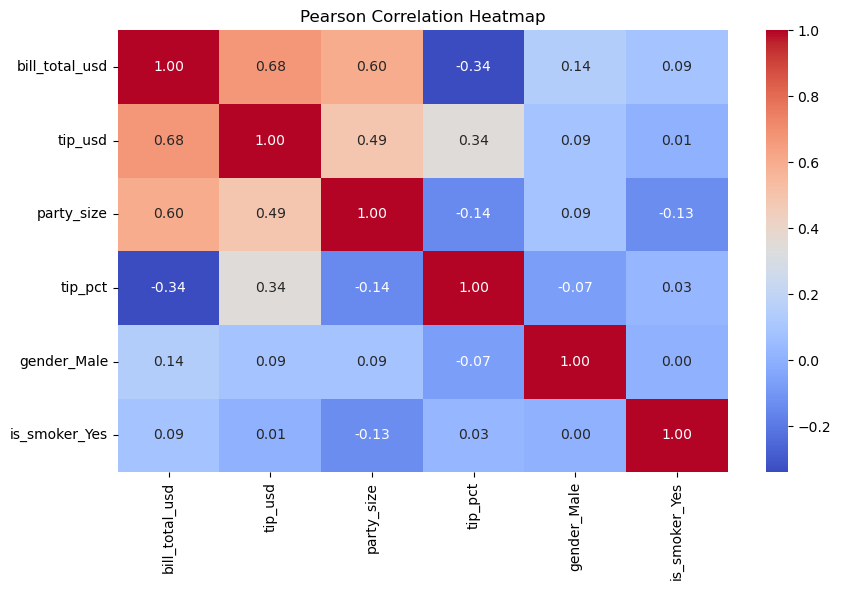

In [18]:
plt.figure(figsize=(9,6))
ax = sns.heatmap(corr_df.corr(method="pearson"), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
# plt.show()


In [19]:

from src.helpers import save_and_log_plot

# --- 2. Save and log the figure ---
save_and_log_plot(
    ax,
    "reports/figures/pearson_correlation_heatmap.png",   # output file
    df=df,
    chart_type="heatmap",
    library="seaborn",
    x=None, y=None,                              # optional for heatmaps
    dataset_name="tips_cleaned",
    dataset_path="data/processed/tips_cleaned.csv",
    notebook="notebooks/07A_Correlation_Diagnostics.ipynb",
    notes="Session 7A: Correlation Diagnostics (Pearson + Spearman)",
    timestamped=True
)

✅ Saved Seaborn Axes figure to: reports/figures/pearson_correlation_heatmap_2025-11-15_1625.png
📝 Logged metadata → reports/figures/pearson_correlation_heatmap_2025-11-15_1625.json


(PosixPath('reports/figures/pearson_correlation_heatmap_2025-11-15_1625.png'),
 PosixPath('reports/figures/pearson_correlation_heatmap_2025-11-15_1625.json'))

| Relationship          | Meaning                                   | Strength              |
| --------------------- | ----------------------------------------- | --------------------- |
| Bill ↑ → Tip ↑        | more expensive meals → bigger dollar tips | **Strong**            |
| Party size ↑ → Bill ↑ | more people → higher bill                 | **Strong**            |
| Party size ↑ → Tip ↑  | more diners → bigger dollar tip           | **Moderate**          |
| Bill ↑ → Tip% ↓       | higher bills → stingier tipping           | **Moderate negative** |
| Gender / Smoker       | no real relationship                      | **None**              |


In [20]:
corr_df.head()

,bill_total_usd,tip_usd,party_size,tip_pct,gender_Male,is_smoker_Yes
0,16.99,1.01,2,0.059447,0,0
1,10.34,1.66,3,0.160542,1,0
2,21.01,3.50,3,0.166587,1,0
3,23.68,3.31,2,0.139780,1,0
4,24.59,3.61,4,0.146808,0,0


Text(0.5, 1.0, 'Spearman Rank Correlation Heatmap')

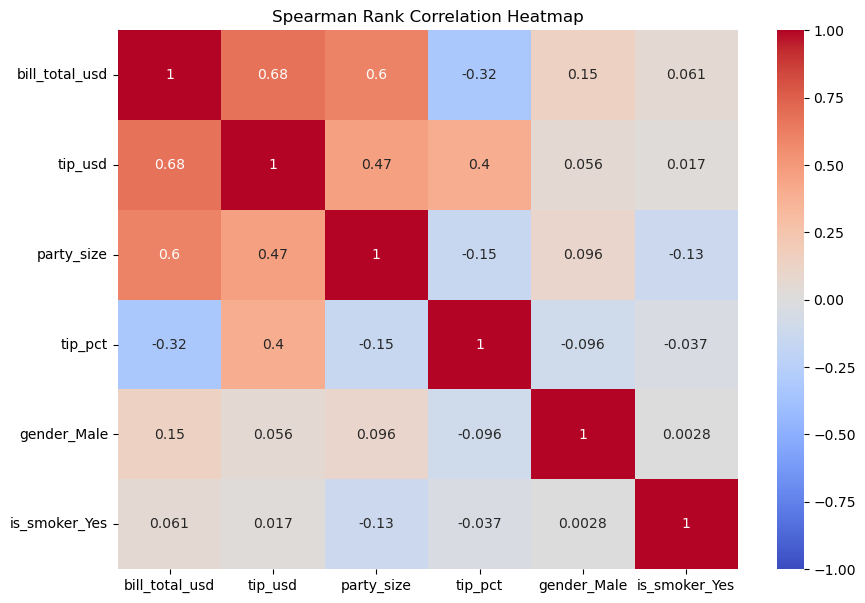

In [24]:

# Compute Spearman rho
spearman_corr = corr_df.corr(method="spearman")

plt.figure(figsize=(10,7))
ax = sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spearman Rank Correlation Heatmap")
# plt.show()

In [25]:
from src.helpers import save_and_log_plot

# --- 2. Save and log the figure ---
save_and_log_plot(
    ax,
    "reports/figures/spearman_correlation_heatmap.png",   # output file
    df=df,
    chart_type="heatmap",
    library="seaborn",
    x=None, y=None,                              # optional for heatmaps
    dataset_name="tips_cleaned",
    dataset_path="data/processed/tips_cleaned.csv",
    notebook="notebooks/07A_Correlation_Diagnostics.ipynb",
    notes="Session 7A: Correlation Diagnostics (Pearson + Spearman)",
    timestamped=True
)

✅ Saved Seaborn Axes figure to: reports/figures/spearman_correlation_heatmap_2025-11-15_1831.png
📝 Logged metadata → reports/figures/spearman_correlation_heatmap_2025-11-15_1831.json


(PosixPath('reports/figures/spearman_correlation_heatmap_2025-11-15_1831.png'),
 PosixPath('reports/figures/spearman_correlation_heatmap_2025-11-15_1831.json'))

## 🧠 ELI5: Spearman Rank Correlation

Spearman correlation answers a simpler question than Pearson:

> “If one variable goes up, does the other ALSO tend to go up,  
> even if the relationship isn’t perfectly straight-line?”

### Key Takeaways
- **bill_total_usd ↔ tip_usd** is still strongly positive →  
  larger bills → larger tips (monotonic pattern).
- **party_size** still rises with both **bill** and **tip**.
- **tip_pct** still drops as **bill totals increase** (negative monotonic trend).
- Gender and smoker status remain essentially **uncorrelated noise**.

Spearman is helpful when:
- data has **nonlinear** relationships  
- variables have **outliers**  
- you care about **rank order**, not exact spacing  


In [27]:
# !pip install pingouin

import pingouin as pg

# Compute partial correlations
# pcorr = pg.partial_corr(data=corr_df, x=None, y=None)

# Compute partial correlation between bill_total_usd and tip_usd.
# pingouin automatically controls for all other numeric columns 
# in corr_df (party_size, tip_pct, gender_Male, is_smoker_Yes).
pcorr = pg.partial_corr(data=corr_df, x='bill_total_usd', y='tip_usd')

pcorr


,n,r,CI95%,p-val
pearson,244,0.675734,"[0.6, 0.74]",6.692471e-34


In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

# corr_df from earlier:
# corr_df = df_enc[["bill_total_usd","tip_usd","party_size","tip_pct","gender_Male","is_smoker_Yes"]]

# 1) Compute partial correlation matrix (controls for all other variables)
pcorr_mat = pg.pcorr(corr_df)   # 👈 this returns a square DataFrame

pcorr_mat


,bill_total_usd,tip_usd,party_size,tip_pct,gender_Male,is_smoker_Yes
bill_total_usd,1.000000,0.845072,0.246377,-0.798394,0.048003,0.279652
tip_usd,0.845072,1.000000,0.092141,0.830144,0.008494,-0.192150
party_size,0.246377,0.092141,1.000000,-0.022767,-0.001662,-0.214239
tip_pct,-0.798394,0.830144,-0.022767,1.000000,-0.018852,0.205750
gender_Male,0.048003,0.008494,-0.001662,-0.018852,1.000000,-0.006543
is_smoker_Yes,0.279652,-0.192150,-0.214239,0.205750,-0.006543,1.000000


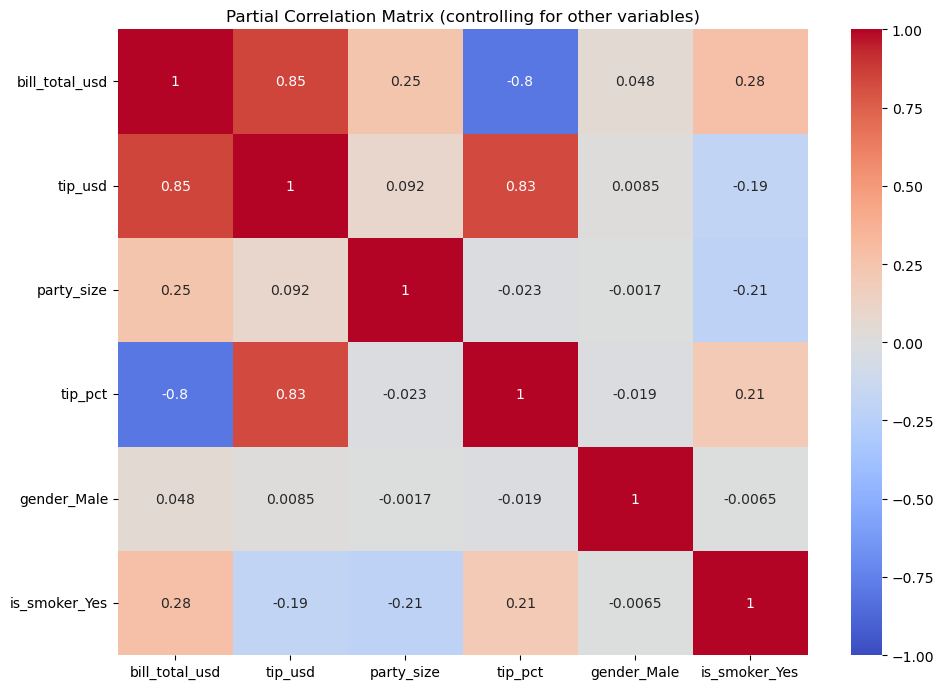

In [32]:
plt.figure(figsize=(10, 7))
ax = sns.heatmap(pcorr_mat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Partial Correlation Matrix (controlling for other variables)")
plt.tight_layout()
# plt.show()


In [33]:
from src.helpers import save_and_log_plot

# --- 2. Save and log the figure ---
save_and_log_plot(
    ax,
    "reports/figures/partial_correlation_heatmap.png",   # output file
    df=df,
    chart_type="heatmap",
    library="seaborn",
    x=None, y=None,                              # optional for heatmaps
    dataset_name="tips_cleaned",
    dataset_path="data/processed/tips_cleaned.csv",
    notebook="notebooks/07A_Correlation_Diagnostics.ipynb",
    notes="Session 7A: Correlation Diagnostics (Pearson + Spearman)",
    timestamped=True
)

✅ Saved Seaborn Axes figure to: reports/figures/partial_correlation_heatmap_2025-11-15_1928.png
📝 Logged metadata → reports/figures/partial_correlation_heatmap_2025-11-15_1928.json


(PosixPath('reports/figures/partial_correlation_heatmap_2025-11-15_1928.png'),
 PosixPath('reports/figures/partial_correlation_heatmap_2025-11-15_1928.json'))

## 🧠 ELI5: Partial Correlation Matrix

**What we did**

- We took the same numeric features as in the Pearson heatmap:
  - `bill_total_usd`, `tip_usd`, `party_size`, `tip_pct`, `gender_Male`, `is_smoker_Yes`
- Then we used `pingouin.pcorr(corr_df)` to compute a **partial correlation matrix**:
  - Each cell shows the correlation between two variables
  - **after removing the influence of all the others** in the table.

**Why this is different from Pearson**

- Pearson: “Do X and Y move together?”
- Partial: “Do X and Y still move together **even after we control for all other features**?”

So if:
- Pearson says `party_size` and `tip_usd` are strongly related,
- but partial correlation between them drops a lot,
- that means much of their relationship was actually explained by another variable  
  (e.g., `bill_total_usd` acting as the real driver).

**How to read the heatmap**

- Values near **+1** → strong positive relationship *after* controlling for others.
- Values near **0** → little unique relationship between that pair.
- Values near **–1** → strong negative relationship after controlling for others.

This helps you see which predictors add **new information** to the model,  
vs. which ones are mostly **overlapping or redundant** once others are included.


In [34]:
import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

# # --- Prepare correlation-ready numeric frame ---
# corr_df = df_enc[["bill_total_usd","tip_usd","party_size","tip_pct",
#                   "gender_Male","is_smoker_Yes"]]

# --- Pearson correlations with tip_usd ---
pearson = corr_df.corr()["tip_usd"].rename("pearson")

# --- Partial correlations with tip_usd ---
partial = {}
for col in corr_df.columns:
    if col == "tip_usd": 
        continue
    
    pc = pg.partial_corr(data=corr_df,
                         x=col,
                         y="tip_usd",
                         covar=[c for c in corr_df.columns if c not in (col, "tip_usd")])
    partial[col] = pc["r"].values[0]

partial = pd.Series(partial, name="partial")

# --- Combine into one comparison table ---
corr_compare = pd.concat([pearson, partial], axis=1).drop("tip_usd", errors="ignore")
corr_compare


,pearson,partial
bill_total_usd,0.675734,0.845072
party_size,0.489299,0.092141
tip_pct,0.342370,0.830144
gender_Male,0.088862,0.008494
is_smoker_Yes,0.005929,-0.192150


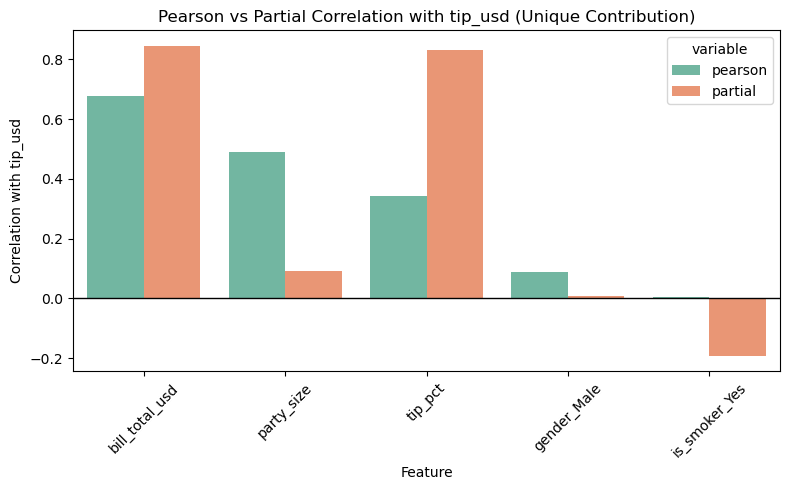

In [37]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=corr_compare.reset_index().melt(id_vars="index"),
            x="index", y="value", hue="variable", palette="Set2")

plt.axhline(0, color="black", lw=1)
plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("Correlation with tip_usd")
plt.title("Pearson vs Partial Correlation with tip_usd (Unique Contribution)")

plt.tight_layout()
# plt.show()


In [38]:
from src.helpers import save_and_log_plot

# --- 2. Save and log the figure ---
save_and_log_plot(
    ax,
    "reports/figures/pearson_partial_correlation_heatmap.png",   # output file
    df=df,
    chart_type="heatmap",
    library="seaborn",
    x=None, y=None,                              # optional for heatmaps
    dataset_name="tips_cleaned",
    dataset_path="data/processed/tips_cleaned.csv",
    notebook="notebooks/07A_Correlation_Diagnostics.ipynb",
    notes="Session 7A: Correlation Diagnostics (Pearson + Spearman)",
    timestamped=True
)

✅ Saved Seaborn Axes figure to: reports/figures/pearson_partial_correlation_heatmap_2025-11-15_1940.png
📝 Logged metadata → reports/figures/pearson_partial_correlation_heatmap_2025-11-15_1940.json


(PosixPath('reports/figures/pearson_partial_correlation_heatmap_2025-11-15_1940.png'),
 PosixPath('reports/figures/pearson_partial_correlation_heatmap_2025-11-15_1940.json'))

## 🧠 ELI5: Why partial correlations matter

We compared **Pearson correlations** (raw relationships) to **partial correlations**  
(relationship after removing the influence of other variables).

### 🍽️ What this means for the tips dataset

- **Pearson** tells us how two things move together *in general*.
- **Partial** tells us whether a feature still matters **after we control for everything else**.

### 🧵 Analogy
Imagine bill size (`bill_total_usd`) and tip size (`tip_usd`) are strongly related.
But `party_size` also increases the bill.

If Pearson says:
- `party_size` is strongly related to `tip_usd`

But partial correlation says:
- the relationship disappears…

…it means `party_size` only looked important because it boosted the bill.  
Once we control for bill size, it adds little unique information.

### 🔍 Why this matters in modeling

Partial correlations tell you:

- Which predictors **add new information**  
- Which predictors are **redundant with others**  
- Which predictors might inflate VIF  
- Which predictors are likely to remain significant in regression

### 🏁 Summary

If a predictor has:
- ⭐ High Pearson **and** high Partial → uniquely useful  
- 🔶 High Pearson but low Partial → overlap with another feature  
- ⚫ Low Pearson and low Partial → weak overall  
- 🔁 Pearson reverses direction vs Partial → strong confounding effect

Partial correlation helps us see **true signal**, not just surface-level patterns.
